# 01 — Baseline: CMA-ES Cat Qubit Optimization

End-to-end demonstration of online optimization for cat qubit stabilization.

**Goal:** Use CMA-ES to tune 4 control knobs $\text{Re}(g_2)$, $\text{Im}(g_2)$, $\text{Re}(\varepsilon_d)$, $\text{Im}(\varepsilon_d)$
to maximize cat qubit lifetimes $T_X$ and $T_Z$ while targeting a bias ratio $\eta = T_Z / T_X$.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings("ignore", message=".*SparseDIAQArray.*converted to a DenseQArray.*")

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import dynamiqs as dq

from src.config import get_config, LOCAL, MEDIUM, HPC
from src.cat_qubit import CatQubitParams, compute_alpha, measure_lifetimes
from src.reward import build_proxy_reward, build_cmaes_loss
from src.optimizers.cmaes_opt import CMAESOptimizer
from src.drift import slow_amplitude_drift, DriftModel

## 1. System Configuration

Choose a **scale profile** to control Hilbert space size, population, and epochs:
- `LOCAL` — fast development (dim=40, ~1–5 min)
- `MEDIUM` — full physics (dim=75, ~10–30 min)
- `HPC` — Palmetto production (dim=200, ~1–4 hours on GPU)

In [2]:
# ============================================================
# SCALE PROFILE — change this one line to scale up/down
# ============================================================
PROFILE = "local"  # "local", "medium", or "hpc"
# ============================================================

cfg = get_config(PROFILE)
params = cfg.cat_params
print(cfg.summary())

# Build proxy reward with config settings
reward_fn, batched_reward_fn = build_proxy_reward(
    params,
    t_probe_z=cfg.reward.t_probe_z,
    t_probe_x=cfg.reward.t_probe_x,
    target_bias=cfg.reward.target_bias,
    w_lifetime=cfg.reward.w_lifetime,
    w_bias=cfg.reward.w_bias,
)

=== RunConfig: local ===
  Hilbert space: na=10, nb=4 (dim=40)
  Hardware: kappa_b=10.0, kappa_a=1.0
  Tasks: [1,2,3]
  CMA-ES: pop=8, epochs=50, sigma0=0.5
  Gradient: lr=0.01, steps=50
  Reward: t_z=30.0, t_x=0.2, target_bias=100.0
  Full eval every 10 epochs
  Benchmark: 1 rewards × 1 optimizers × 1 drifts
    Rewards: ['proxy']
    Optimizers: ['cmaes']
    Drifts: ['none']



## 2. Verify Default Parameters

Before optimization, verify that the default control parameters
($g_2 = 1$, $\varepsilon_d = 4$ from the challenge notebook) produce reasonable lifetimes.

In [3]:
# Default parameters from challenge notebook
x_default = jnp.array([1.0, 0.0, 4.0, 0.0])

alpha = compute_alpha(1.0, 0.0, 4.0, 0.0, params)
print(f'Estimated cat size α = {alpha:.4f}')
print(f'Expected <n> ≈ |α|² = {alpha**2:.2f}')

# Warm up JIT compilation with proxy reward
print('\nCompiling proxy reward (first call, may take ~1 min)...')
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    r = reward_fn(x_default)
print(f'Proxy reward at default params: {r:.4f}')

# Full T_X/T_Z measurement for ground truth
print('\nMeasuring full lifetimes (2 simulations + fitting)...')
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lifetimes = measure_lifetimes(1.0, 0.0, 4.0, 0.0, params=params)
print(f'T_Z = {lifetimes["Tz"]:.2f} μs')
print(f'T_X = {lifetimes["Tx"]:.4f} μs')
print(f'Bias η = T_Z/T_X = {lifetimes["bias"]:.1f}')

Estimated cat size α = 1.6583
Expected <n> ≈ |α|² = 2.75

Compiling proxy reward (first call, may take ~1 min)...
Proxy reward at default params: 1.6607

Measuring full lifetimes (2 simulations + fitting)...
T_Z = 37.21 μs
T_X = 0.1788 μs
Bias η = T_Z/T_X = 208.1


## 3. CMA-ES Optimization (No Drift)

Optimize the 4 control knobs to maximize the proxy reward.
CMA-ES explores the parameter space by sampling populations from
a multivariate Gaussian $\mathcal{N}(\boldsymbol{\mu}, \sigma^2 \mathbf{C})$
and adapting toward better-performing regions.

In [4]:
# CMA-ES hyperparameters from config
N_EPOCHS = cfg.optimizer.n_epochs
POPULATION_SIZE = cfg.optimizer.population_size

optimizer = CMAESOptimizer(
    mean0=np.array([1.5, 0.0, 6.0, 0.0]),  # start away from optimum
    sigma0=cfg.optimizer.sigma0,
    population_size=POPULATION_SIZE,
    seed=cfg.optimizer.seed,
)

# Logging
mean_history = []
reward_history = []
reward_std_history = []

# Compile batched reward
print('Compiling batched reward...')
xs_test = optimizer.ask()
_ = batched_reward_fn(xs_test)
print('Compilation done. Starting optimization...\n')

for epoch in range(N_EPOCHS):
    # Sample population
    xs = optimizer.ask()
    
    # Evaluate rewards (batched, JIT-compiled)
    rewards = batched_reward_fn(xs)
    
    # Update optimizer
    optimizer.tell(xs, rewards)
    
    # Log
    mean_history.append(np.array(optimizer.mean))
    reward_history.append(float(jnp.mean(rewards)))
    reward_std_history.append(float(jnp.std(rewards)))
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | mean={optimizer.mean} | '
              f'avg reward={jnp.mean(rewards):.4f} | \u03c3={optimizer.sigma:.4f}')

mean_history = np.array(mean_history)
reward_history = np.array(reward_history)
reward_std_history = np.array(reward_std_history)

print(f'\nFinal mean: {optimizer.mean}')
print(f'Best params: {optimizer.get_best()}')

Compiling batched reward...
Compilation done. Starting optimization...

Epoch   0 | mean=[ 1.6413183  -0.7245018   5.6707325  -0.07005996] | avg reward=0.7875 | σ=0.5434
Epoch  10 | mean=[ 3.927691   0.8691264  7.0900536 -1.4662697] | avg reward=2.3933 | σ=1.3261
Epoch  20 | mean=[ 4.718003   1.5055326  7.224477  -2.410833 ] | avg reward=2.9055 | σ=0.8799
Epoch  30 | mean=[ 4.9611382  1.9456416  7.741913  -2.8721256] | avg reward=2.9686 | σ=0.3735
Epoch  40 | mean=[ 4.987451   1.9646463  7.78118   -3.015873 ] | avg reward=2.9767 | σ=0.2021

Final mean: [ 4.9988337  1.9950596  7.7844224 -3.078339 ]
Best params: [ 4.9998317  1.9956872  7.781078  -3.065991 ]


## 4. Results Visualization

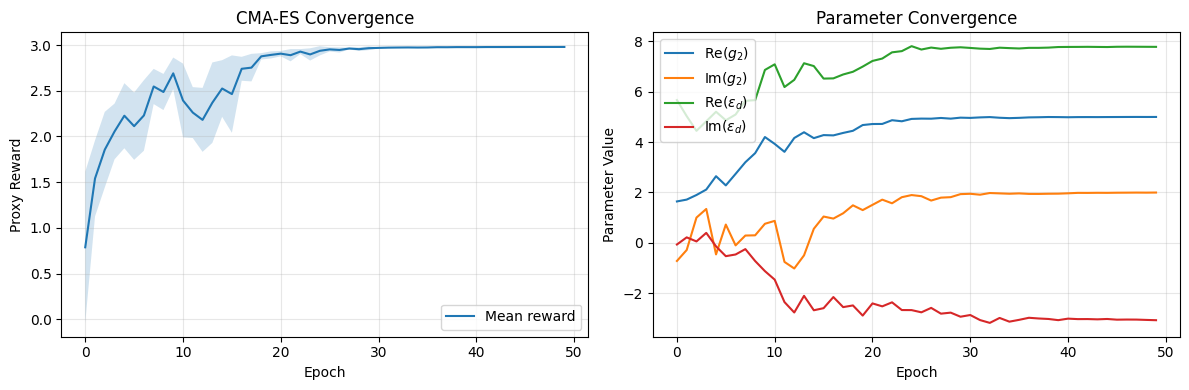

In [5]:
epochs = np.arange(N_EPOCHS)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Reward vs epoch
ax = axes[0]
ax.plot(epochs, reward_history, label='Mean reward')
ax.fill_between(
    epochs,
    reward_history - reward_std_history,
    reward_history + reward_std_history,
    alpha=0.2,
)
ax.set_xlabel('Epoch')
ax.set_ylabel('Proxy Reward')
ax.set_title('CMA-ES Convergence')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Parameter convergence
ax = axes[1]
labels = [r'Re($g_2$)', r'Im($g_2$)', r'Re($\epsilon_d$)', r'Im($\epsilon_d$)']
for i, label in enumerate(labels):
    ax.plot(epochs, mean_history[:, i], label=label)
ax.set_xlabel('Epoch')
ax.set_ylabel('Parameter Value')
ax.set_title('Parameter Convergence')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/01_cmaes_convergence.png', dpi=200, bbox_inches='tight')
plt.show()

## 5. Validate with Full Lifetime Measurement

Use the optimized parameters to measure actual $T_X$, $T_Z$, and bias $\eta$
via full exponential decay fitting (ground truth).

In [6]:
best = optimizer.get_best()
print(f'Optimized params: g₂ = {best[0]:.4f} + {best[1]:.4f}j, '
      f'ε_d = {best[2]:.4f} + {best[3]:.4f}j')

alpha_opt = compute_alpha(float(best[0]), float(best[1]), 
                          float(best[2]), float(best[3]), params)
print(f'Optimized cat size α = {alpha_opt:.4f}')

print('\nMeasuring full lifetimes at optimized params...')
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lt_opt = measure_lifetimes(float(best[0]), float(best[1]),
                               float(best[2]), float(best[3]), params=params)
print(f'T_Z = {lt_opt["Tz"]:.2f} μs')
print(f'T_X = {lt_opt["Tx"]:.4f} μs')
print(f'Bias η = {lt_opt["bias"]:.1f}')

print(f'\n--- Comparison ---')
print(f'{"":20s} {"Default":>12s} {"Optimized":>12s}')
print(f'{"T_Z [μs]":20s} {lifetimes["Tz"]:12.2f} {lt_opt["Tz"]:12.2f}')
print(f'{"T_X [μs]":20s} {lifetimes["Tx"]:12.4f} {lt_opt["Tx"]:12.4f}')
print(f'{"Bias η":20s} {lifetimes["bias"]:12.1f} {lt_opt["bias"]:12.1f}')
print(f'{"α":20s} {float(alpha):12.4f} {float(alpha_opt):12.4f}')

Optimized params: g₂ = 4.9998 + 1.9957j, ε_d = 7.7811 + -3.0660j
Optimized cat size α = 1.2290

Measuring full lifetimes at optimized params...
T_Z = 49.15 μs
T_X = 0.3495 μs
Bias η = 140.6

--- Comparison ---
                          Default    Optimized
T_Z [μs]                    37.21        49.15
T_X [μs]                   0.1788       0.3495
Bias η                      208.1        140.6
α                          1.6583       1.2290


## Full Benchmark Sweep

Run all configured reward x optimizer x drift combinations using the benchmark framework.
This sweeps over the Cartesian product defined in the config profile.

In [ ]:
# Configure what to sweep — edit these lists to control scope
cfg.benchmark.rewards = ["proxy", "photon", "fidelity", "parity"]
cfg.benchmark.optimizers = ["cmaes", "gradient", "hybrid", "ppo", "bayesian"]
cfg.benchmark.drifts = ["none", "amplitude_slow", "frequency"]

from src.benchmark import run_benchmark

print(f'Running {len(cfg.benchmark.rewards)} rewards x '
      f'{len(cfg.benchmark.optimizers)} optimizers x '
      f'{len(cfg.benchmark.drifts)} drifts = '
      f'{len(cfg.benchmark.rewards) * len(cfg.benchmark.optimizers) * len(cfg.benchmark.drifts)} combinations\n')

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    benchmark_results = run_benchmark(cfg, verbose=True)

## Benchmark Results Overview

In [ ]:
from src.plotting import (
    plot_reward_convergence,
    plot_reward_type_comparison,
    plot_summary_heatmap,
)

# Convergence by optimizer
plot_reward_convergence(benchmark_results, group_by='optimizer',
                        save_path='../figures/01_benchmark_convergence.png')

# Reward type comparison (no-drift runs only)
no_drift = [r for r in benchmark_results if r.drift_type == 'none']
if no_drift:
    plot_reward_type_comparison(no_drift,
                                save_path='../figures/01_reward_comparison.png')

# Summary heatmap
plot_summary_heatmap(benchmark_results, metric='final_reward',
                      save_path='../figures/01_summary_heatmap.png')

# Print summary table
print(f'\n{"Optimizer":<12s} {"Reward":<10s} {"Drift":<16s} {"Final R":>9s} {"Best R":>9s} {"Time":>7s}')
print("-" * 67)
for r in benchmark_results:
    final = r.reward_history[-1] if r.reward_history else float("nan")
    best = max(r.reward_history) if r.reward_history else float("nan")
    print(f'{r.optimizer_type:<12s} {r.reward_type:<10s} {r.drift_type:<16s} '
          f'{final:>9.4f} {best:>9.4f} {r.wall_time:>6.1f}s')

## 6. CMA-ES Under Drift

Now test the optimizer's ability to track slow amplitude drift on $g_2$.
The drift follows:

$$g_{2,\text{eff}} = g_2 \cdot \left(1 + 0.3 \sin(2\pi \cdot 0.005 \cdot \text{epoch})\right)$$

with period = 200 epochs.

In [ ]:
from src.reward import _build_proxy_loss_fn
from jax import jit, vmap

# Build a proxy reward that accepts extended vector [control | drift_offsets]
a_op, b_op = None, None  # Will use inline construction

# For drift, we construct the loss inline following the challenge notebook pattern
from src.cat_qubit import build_operators, build_hamiltonian, build_jump_ops, build_logical_ops

a, b = build_operators(params)
jump_ops = build_jump_ops(a, b, params)

N_KNOBS = 4
T_PROBE_Z = cfg.reward.t_probe_z
T_PROBE_X = cfg.reward.t_probe_x

@jit
def proxy_reward_with_drift(p):
    """Reward function that accepts [control_knobs | drift_offsets]."""
    # Control params (optimizer tunes these)
    g2_re, g2_im, eps_d_re, eps_d_im = p[0], p[1], p[2], p[3]
    # Drift offsets (injected by training loop)
    g2_re_drift = p[N_KNOBS + 0]
    g2_im_drift = p[N_KNOBS + 1]
    
    # Effective parameters = control - drift
    g2_re_eff = g2_re - g2_re_drift
    g2_im_eff = g2_im - g2_im_drift
    
    H = build_hamiltonian(a, b, g2_re_eff, g2_im_eff, eps_d_re, eps_d_im)
    alpha = compute_alpha(g2_re_eff, g2_im_eff, eps_d_re, eps_d_im, params)
    sx, sz = build_logical_ops(a, b, alpha, params)
    
    # Measure <Z_L> at t_probe_z from |+z>
    g_state = dq.coherent(params.na, alpha)
    psi_z = dq.tensor(g_state, dq.fock(params.nb, 0))
    res_z = dq.mesolve(H, jump_ops, psi_z, jnp.array([0.0, T_PROBE_Z]),
                       exp_ops=[sx, sz], options=dq.Options(progress_meter=False))
    ez = res_z.expects[1, -1].real
    
    # Measure <X_L> at t_probe_x from |+x>
    e_state = dq.coherent(params.na, -alpha)
    psi_x = dq.tensor(dq.unit(g_state + e_state), dq.fock(params.nb, 0))
    res_x = dq.mesolve(H, jump_ops, psi_x, jnp.array([0.0, T_PROBE_X]),
                       exp_ops=[sx, sz], options=dq.Options(progress_meter=False))
    ex = res_x.expects[0, -1].real
    
    ez_safe = jnp.maximum(ez, 1e-6)
    ex_safe = jnp.maximum(jnp.abs(ex), 1e-6)
    lifetime_score = jnp.log(ez_safe) + jnp.log(ex_safe)
    
    log_ez = jnp.minimum(jnp.log(ez_safe), -1e-6)
    log_ex = jnp.minimum(jnp.log(ex_safe), -1e-6)
    bias_proxy = (T_PROBE_Z / T_PROBE_X) * (log_ex / log_ez)
    bias_penalty = -0.5 * (jnp.log(bias_proxy + 1e-6) - jnp.log(100.0)) ** 2
    
    return lifetime_score + bias_penalty

batched_proxy_drift = jit(vmap(proxy_reward_with_drift))

print('Compiling drift reward...')
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    _ = proxy_reward_with_drift(jnp.zeros(N_KNOBS + 2))
print('Done.')

In [8]:
# Drift scenario: slow sinusoidal g2 amplitude drift
drift_model = slow_amplitude_drift()
print(f'Drift: {drift_model.describe()}')

N_EPOCHS_DRIFT = 200

optimizer_drift = CMAESOptimizer(
    mean0=np.array([1.0, 0.0, 4.0, 0.0]),
    sigma0=0.3,
    population_size=12,
    seed=42,
    sigma_floor=0.05,  # prevent convergence for drift tracking
)

# Logging
drift_mean_history = []
drift_reward_history = []
drift_offset_history = []

for epoch in range(N_EPOCHS_DRIFT):
    # Get drift offsets at this epoch
    offsets = drift_model.get_control_offsets(epoch)
    drift_vec = [offsets['g2_re_offset'], offsets['g2_im_offset']]
    
    # Sample candidates and append drift
    xs_control = optimizer_drift.ask()
    xs_full = jnp.concatenate([
        xs_control,
        jnp.broadcast_to(jnp.array(drift_vec), (xs_control.shape[0], 2))
    ], axis=1)
    
    # Evaluate
    rewards = batched_proxy_drift(xs_full)
    
    # Tell optimizer (only control knobs)
    optimizer_drift.tell(xs_control, rewards)
    
    # Log
    drift_mean_history.append(np.array(optimizer_drift.mean))
    drift_reward_history.append(float(jnp.mean(rewards)))
    drift_offset_history.append(drift_vec)
    
    if epoch % 20 == 0:
        print(f'Epoch {epoch:3d} | g2_re_drift={drift_vec[0]:.3f} | '
              f'mean_g2_re={optimizer_drift.mean[0]:.3f} | '
              f'reward={jnp.mean(rewards):.4f}')

drift_mean_history = np.array(drift_mean_history)
drift_reward_history = np.array(drift_reward_history)
drift_offset_history = np.array(drift_offset_history)

Drift: AmplitudeDrift(A=0.3, f=0.005)
Epoch   0 | g2_re_drift=0.000 | mean_g2_re=1.249 | reward=-3.0362
Epoch  20 | g2_re_drift=0.176 | mean_g2_re=4.697 | reward=-1.8299
Epoch  40 | g2_re_drift=0.285 | mean_g2_re=4.966 | reward=-1.7474
Epoch  60 | g2_re_drift=0.285 | mean_g2_re=4.999 | reward=-1.7427
Epoch  80 | g2_re_drift=0.176 | mean_g2_re=5.000 | reward=-1.7388
Epoch 100 | g2_re_drift=-0.000 | mean_g2_re=5.000 | reward=-1.7332
Epoch 120 | g2_re_drift=-0.176 | mean_g2_re=5.000 | reward=-1.7282
Epoch 140 | g2_re_drift=-0.285 | mean_g2_re=5.000 | reward=-1.7253
Epoch 160 | g2_re_drift=-0.285 | mean_g2_re=5.000 | reward=-1.7252
Epoch 180 | g2_re_drift=-0.176 | mean_g2_re=5.000 | reward=-1.7281


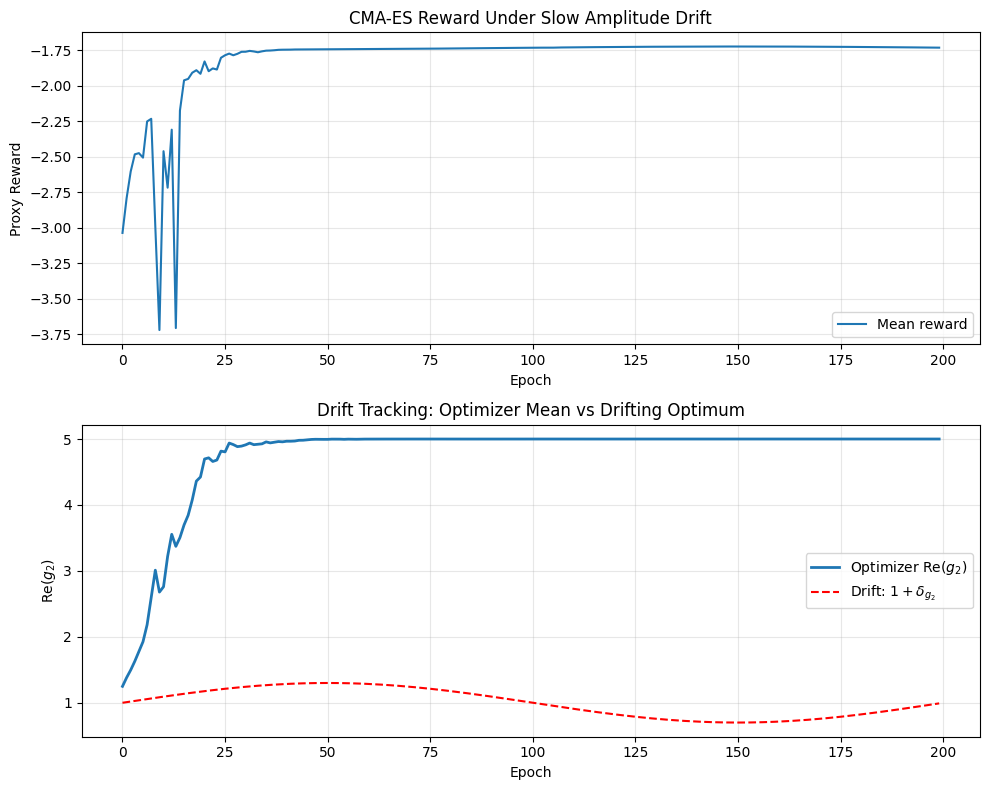

In [9]:
epochs_d = np.arange(N_EPOCHS_DRIFT)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Plot 1: Reward under drift
ax = axes[0]
ax.plot(epochs_d, drift_reward_history, label='Mean reward')
ax.set_xlabel('Epoch')
ax.set_ylabel('Proxy Reward')
ax.set_title('CMA-ES Reward Under Slow Amplitude Drift')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Parameter tracking vs drift
ax = axes[1]
# The optimizer's g2_re should track the drift offset to compensate
ax.plot(epochs_d, drift_mean_history[:, 0], label=r'Optimizer Re($g_2$)', linewidth=2)
ax.plot(epochs_d, 1.0 + drift_offset_history[:, 0], 
        label=r'Drift: $1 + \delta_{g_2}$', linestyle='--', color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel(r'Re($g_2$)')
ax.set_title('Drift Tracking: Optimizer Mean vs Drifting Optimum')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/01_drift_tracking.png', dpi=200, bbox_inches='tight')
plt.show()

## Summary

- CMA-ES successfully optimizes 4 control knobs for cat qubit stabilization
- Proxy reward (single-point expectation values at $t_{\text{probe}}$) is fast and JIT-compatible
- Under slow amplitude drift, CMA-ES tracks the drifting optimum
- Sigma floor ($\sigma_{\min} > 0$) prevents premature convergence during drift tracking
- Scale profile: change `PROFILE` variable to switch between local/medium/HPC runs